# NEHRP Categorical vs Continuous Vs30 Experiment

## Objective
Test if using categorical NEHRP classes directly (A/B/C/D/E) instead of continuous Vs30 maintains model performance.

## Decision Criteria
- **Excellent**: R² drop < 3% (R² > 0.87)
- **Acceptable**: R² drop 3-5% (R² > 0.85)
- **Not Recommended**: R² drop > 5% (R² < 0.85)

Baseline R² with continuous Vs30: **0.904224**

In [1]:
# Import dependencies
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from pytorch_tabnet.tab_model import TabNetRegressor
import matplotlib.pyplot as plt

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.6.0+cu124
CUDA available: True


In [2]:
# Configuration
NGA_FILE = "../dataset/Updated_NGA_West2_Flatfile_RotD50_d050_public_version.xlsx"

BEST_CONFIG = {
    "n_d": 64,
    "n_steps": 3,
    "momentum": 0.01,
    "lambda_sparse": 0.001,
    "lr": 0.003,
    "batch_size": 256,
}

BASELINE_R2 = 0.904224
N_EPOCHS = 100
PATIENCE = 10
RANDOM_SEED = 42
TEST_SIZE = 0.2

# Himalayan periods from tabnet-himalaya setup (used to align output space)
HIM_PERIODS = [
    "T0.010S", "T0.020S", "T0.030S", "T0.040S", "T0.050S", "T0.060S",
    "T0.070S", "T0.080S", "T0.090S", "T0.100S", "T0.150S", "T0.200S",
    "T0.250S", "T0.300S", "T0.400S", "T0.500S", "T0.800S", "T1.000S",
    "T1.200S", "T1.500S", "T1.800S", "T2.000S", "T2.500S", "T3.000S",
    "T3.500S", "T4.000S", "T5.000S",
]

def period_to_float(col_name):
    return float(col_name[1:-1])

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

print(f"Configuration: {BEST_CONFIG}")
print(f"Baseline R2: {BASELINE_R2}")
print(f"Data file: {NGA_FILE}")

Configuration: {'n_d': 64, 'n_steps': 3, 'momentum': 0.01, 'lambda_sparse': 0.001, 'lr': 0.003, 'batch_size': 256}
Baseline R2: 0.904224
Data file: ../dataset/Updated_NGA_West2_Flatfile_RotD50_d050_public_version.xlsx


In [3]:
# Load NGA-West2 data from XLSX (same source as tabnet notebooks)
df_temp = pd.read_excel(NGA_FILE, engine="calamine", nrows=0)
period_cols = [c for c in df_temp.columns if c.startswith("T") and c.endswith("S")]
sa_cols_le_4s = sorted(
    [c for c in period_cols if period_to_float(c) <= 4.0],
    key=period_to_float,
)
common_periods = sorted(set(HIM_PERIODS) & set(sa_cols_le_4s), key=period_to_float)

use_cols = [
    "Earthquake Magnitude",
    "Joyner-Boore Dist. (km)",
    "Mechanism Based on Rake Angle",
    "Preferred NEHRP Based on Vs30",
    "PGA (g)",
] + common_periods

nga_df = pd.read_excel(NGA_FILE, engine="calamine", usecols=use_cols)
print(f"Original NGA-West2 dataset shape: {nga_df.shape}")
print(f"Common periods used: {len(common_periods)}")
print(nga_df["Preferred NEHRP Based on Vs30"].value_counts(dropna=False).head(12))

Original NGA-West2 dataset shape: (21540, 31)
Common periods used: 26
Preferred NEHRP Based on Vs30
C       13276
D        6759
B        1255
E         208
-999       24
A           9
D/E         4
C/D         2
D-E         2
NaN         1
Name: count, dtype: int64


In [4]:
# Clean data and remove ambiguous NEHRP classes
valid_classes = ["A", "B", "C", "D", "E"]
class_col = "Preferred NEHRP Based on Vs30"

# Keep only rows with valid class and positive values for required predictors/targets
required_positive = ["Joyner-Boore Dist. (km)", "PGA (g)"] + common_periods
nga_clean = nga_df[nga_df[class_col].isin(set(valid_classes))].copy()
for col in required_positive:
    nga_clean = nga_clean[nga_clean[col] > 0]

# Drop NaN / inf rows across key columns
subset_cols = [
    "Earthquake Magnitude",
    "Joyner-Boore Dist. (km)",
    "Mechanism Based on Rake Angle",
    class_col,
    "PGA (g)",
] + common_periods
nga_clean = nga_clean.replace([np.inf, -np.inf], np.nan).dropna(subset=subset_cols).reset_index(drop=True)

# Log transforms aligned with tabnet-himalaya output space
nga_clean["log10_Rjb"] = np.log10(nga_clean["Joyner-Boore Dist. (km)"])
nga_clean["log10_PGA"] = np.log10(nga_clean["PGA (g)"])
for p in common_periods:
    nga_clean[f"log10_{p}"] = np.log10(nga_clean[p])

print(f"After cleaning: {nga_clean.shape}")
print(nga_clean[class_col].value_counts().sort_index())

After cleaning: (21222, 59)
Preferred NEHRP Based on Vs30
A        8
B     1241
C    13120
D     6646
E      207
Name: count, dtype: int64


In [5]:
# Encode NEHRP classes and create numeric Vs30 proxy
nehrp_mapping = {"A": 1, "B": 2, "C": 3, "D": 4, "E": 5}
nga_clean["NEHRP_encoded"] = nga_clean["Preferred NEHRP Based on Vs30"].map(nehrp_mapping)

# Representative Vs30 means per NEHRP class (m/s)
class_mean_vs30 = {
    "A": 2000.0,  # A is open-ended (>1500), use a conservative representative value
    "B": 1130.0,  # midpoint of 760-1500
    "C": 560.0,   # midpoint of 360-760
    "D": 270.0,   # midpoint of 180-360
    "E": 120.0,   # E is open-ended (<180), use a conservative representative value
}
nga_clean["Vs30_proxy"] = nga_clean["Preferred NEHRP Based on Vs30"].map(class_mean_vs30).astype("float32")
nga_clean["log10_Vs30_proxy"] = np.log10(nga_clean["Vs30_proxy"])

print(f"NEHRP encoding: {nehrp_mapping}")
print(f"Class mean Vs30 proxy (m/s): {class_mean_vs30}")
print(nga_clean[["Preferred NEHRP Based on Vs30", "Vs30_proxy", "log10_Vs30_proxy"]].head())

NEHRP encoding: {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5}
Class mean Vs30 proxy (m/s): {'A': 2000.0, 'B': 1130.0, 'C': 560.0, 'D': 270.0, 'E': 120.0}
  Preferred NEHRP Based on Vs30  Vs30_proxy  log10_Vs30_proxy
0                             C       560.0          2.748188
1                             C       560.0          2.748188
2                             D       270.0          2.431364
3                             D       270.0          2.431364
4                             D       270.0          2.431364


In [6]:
# Define input and output features (aligned to transfer experiment output space)
input_features = [
    "Earthquake Magnitude",
    "Joyner-Boore Dist. (km)",
    "Mechanism Based on Rake Angle",
    "log10_Vs30_proxy",
    "log10_Rjb",
]
output_features = ["log10_PGA"] + [f"log10_{p}" for p in common_periods]

nga_clean = nga_clean.dropna(subset=input_features + output_features).reset_index(drop=True)

print(f"Input features ({len(input_features)}): {input_features}")
print(f"Output features ({len(output_features)}): first 3 -> {output_features[:3]}")
print(f"Final dataset shape: {nga_clean.shape}")

Input features (5): ['Earthquake Magnitude', 'Joyner-Boore Dist. (km)', 'Mechanism Based on Rake Angle', 'log10_Vs30_proxy', 'log10_Rjb']
Output features (27): first 3 -> ['log10_PGA', 'log10_T0.010S', 'log10_T0.020S']
Final dataset shape: (21222, 62)


## Inputs and Outputs Used by the Model

### Inputs (`X`)
The model uses 5 predictors:

1. `Earthquake Magnitude`
2. `Joyner-Boore Dist. (km)`
3. `Mechanism Based on Rake Angle`
4. `log10_Vs30_proxy` (derived from NEHRP class mean Vs30)
5. `log10_Rjb`

### Outputs (`y`)
The model predicts multiple targets simultaneously:

1. `log10_PGA`
2. `log10_T*` spectral ordinates for each `common_period` shared with Himalayan setup (and <= 4.0 s)

So output dimensionality is: `1 + len(common_periods)` targets per sample.

In [7]:
# Train/test split and scaling
X = nga_clean[input_features].values.astype("float32")
y = nga_clean[output_features].values.astype("float32")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED
)

print(f"Train set: {X_train.shape}, Test set: {X_test.shape}")

x_scaler = StandardScaler()
y_scaler = StandardScaler()
X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)
y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

print("Feature and target scaling completed")

Train set: (16977, 5), Test set: (4245, 5)
Feature and target scaling completed


In [8]:
# Train TabNet model
print("Training TabNet model with NEHRP categorical classes...")

tabnet = TabNetRegressor(
    n_d=BEST_CONFIG["n_d"],
    n_a=BEST_CONFIG["n_d"],
    n_steps=BEST_CONFIG["n_steps"],
    momentum=BEST_CONFIG["momentum"],
    lambda_sparse=BEST_CONFIG["lambda_sparse"],
    optimizer_fn=torch.optim.Adam,
    optimizer_params={"lr": BEST_CONFIG["lr"]},
    device_name="cuda" if torch.cuda.is_available() else "cpu",
    seed=RANDOM_SEED,
    verbose=10,
 )

tabnet.fit(
    X_train_scaled,
    y_train_scaled,
    eval_set=[(X_test_scaled, y_test_scaled)],
    eval_metric=["mse"],
    max_epochs=N_EPOCHS,
    patience=PATIENCE,
    batch_size=BEST_CONFIG["batch_size"],
    virtual_batch_size=max(8, BEST_CONFIG["batch_size"] // 4),
    num_workers=0,
    drop_last=False,
 )

print("Training completed")

Training TabNet model with NEHRP categorical classes...


c:\Users\suggu\miniconda3\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.87131 | val_0_mse: 0.22404 |  0:00:02s
epoch 10 | loss: 0.13752 | val_0_mse: 0.11747 |  0:00:23s
epoch 20 | loss: 0.12266 | val_0_mse: 0.10763 |  0:00:42s
epoch 30 | loss: 0.11778 | val_0_mse: 0.10714 |  0:01:04s
epoch 40 | loss: 0.11625 | val_0_mse: 0.1063  |  0:01:24s

Early stopping occurred at epoch 42 with best_epoch = 32 and best_val_0_mse = 0.10432


c:\Users\suggu\miniconda3\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Training completed


In [9]:
# Evaluate model
y_pred_scaled = tabnet.predict(X_test_scaled)
y_pred = y_scaler.inverse_transform(y_pred_scaled)
y_true = y_test

r2 = r2_score(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print("=" * 60)
print("TEST SET PERFORMANCE")
print("=" * 60)
print(f"R2 Score:  {r2:.6f}")
print(f"MAE:       {mae:.6f}")
print(f"RMSE:      {rmse:.6f}")
print("=" * 60)

TEST SET PERFORMANCE
R2 Score:  0.892574
MAE:       0.301547
RMSE:      0.389643


In [10]:
# Compare with baseline
r2_drop_percent = ((BASELINE_R2 - r2) / BASELINE_R2) * 100
r2_drop_absolute = BASELINE_R2 - r2

print("\n" + "=" * 60)
print("COMPARISON WITH BASELINE (Continuous Vs30)")
print("=" * 60)
print(f"Baseline R2 (Continuous Vs30): {BASELINE_R2:.6f}")
print(f"Current R2 (NEHRP Classes):    {r2:.6f}")
print(f"Absolute Drop:                 {r2_drop_absolute:.6f}")
print(f"Percentage Drop:               {r2_drop_percent:.2f}%")
print("=" * 60)


COMPARISON WITH BASELINE (Continuous Vs30)
Baseline R2 (Continuous Vs30): 0.904224
Current R2 (NEHRP Classes):    0.892574
Absolute Drop:                 0.011650
Percentage Drop:               1.29%


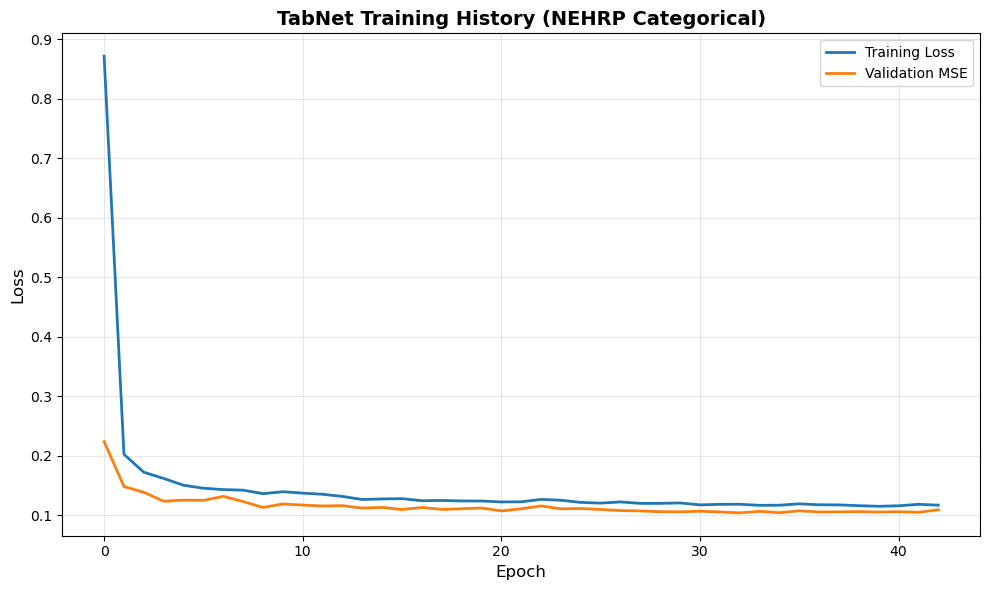

Best epoch: 32


In [11]:
# Visualize training history
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(tabnet.history["loss"], label="Training Loss", linewidth=2)
ax.plot(tabnet.history["val_0_mse"], label="Validation MSE", linewidth=2)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.set_title("TabNet Training History (NEHRP Categorical)", fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best epoch: {tabnet.best_epoch}")

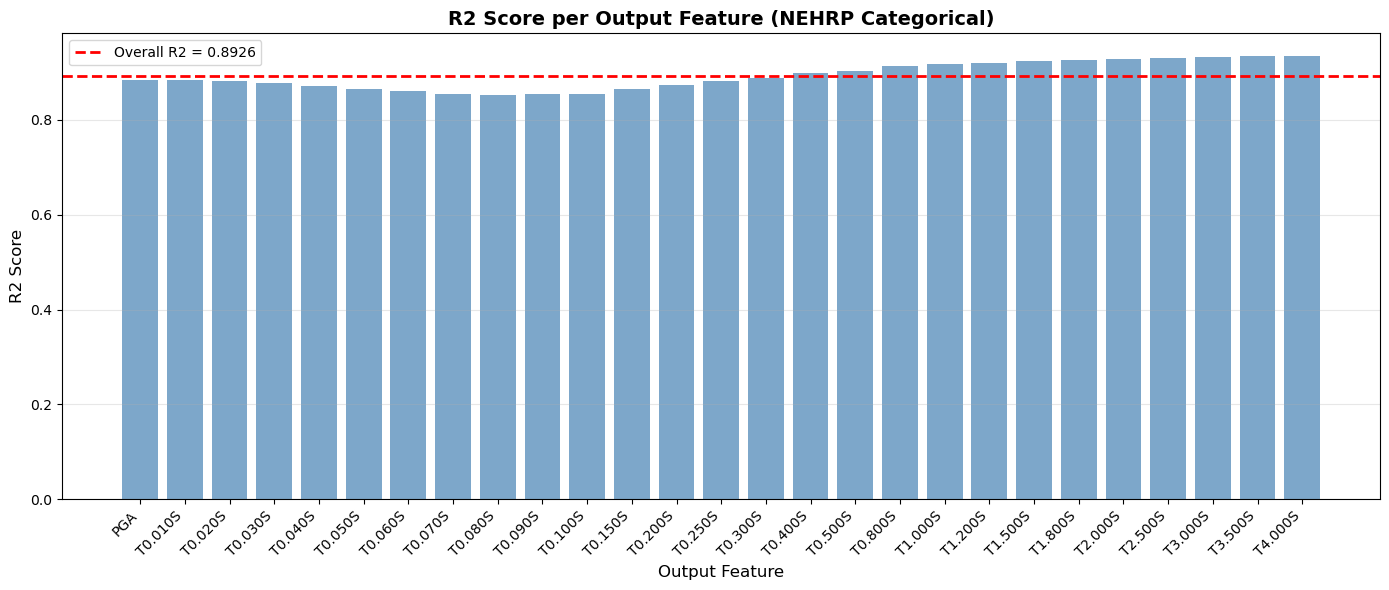

Mean R2 across outputs: 0.892574
Min R2: 0.852865 (log10_T0.080S)
Max R2: 0.935142 (log10_T3.500S)


In [12]:
# Visualize R2 per output feature
r2_per_output = [r2_score(y_true[:, i], y_pred[:, i]) for i in range(y_true.shape[1])]

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(range(len(output_features)), r2_per_output, color="steelblue", alpha=0.7)
ax.set_xlabel("Output Feature", fontsize=12)
ax.set_ylabel("R2 Score", fontsize=12)
ax.set_title("R2 Score per Output Feature (NEHRP Categorical)", fontsize=14, fontweight="bold")
ax.set_xticks(range(len(output_features)))
ax.set_xticklabels([col.replace("log10_", "") for col in output_features], rotation=45, ha="right")
ax.axhline(y=r2, color="red", linestyle="--", linewidth=2, label=f"Overall R2 = {r2:.4f}")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mean R2 across outputs: {np.mean(r2_per_output):.6f}")
print(f"Min R2: {np.min(r2_per_output):.6f} ({output_features[int(np.argmin(r2_per_output))]})")
print(f"Max R2: {np.max(r2_per_output):.6f} ({output_features[int(np.argmax(r2_per_output))]})")

## Summary

This experiment uses categorical NEHRP site classes to derive a numeric Vs30 proxy (class-mean Vs30), then feeds `log10(Vs30_proxy)` to the model.

### Key Findings
- Source and target representations stay aligned through NEHRP classes
- Model receives a physically meaningful numeric site parameter (`log10_Vs30_proxy`)
- Removes brittle class-to-single-point ad hoc mapping during transfer
- Performance impact can now be interpreted against a numeric Vs30-style input rather than raw class codes